In [1]:
import sys

sys.path.append('src')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from patsy import dmatrix
from scipy import stats

from utils import calibration_by

plt.style.use('ggplot')
rng = np.random.default_rng(42)

# Prespecifying Model Complexity

In the previous notebook we saw how to build flexible fits with splines. In this notebook, we take a step back and ask a broader question: Given a full model with several predictors and a limited amount of data, how much flexibility should each predictor get?

Whenever we fit a model to the data, we assume that the sample we have reflects the population perfectly. Or, more technically, that they come from the same distribution. However, this is a very naive assumption. When our model learns every pattern in our data, it also learns the noise patterns. This decreases its generalization (fit/perform well on different samples) power. This is called overfitting.

On the flip side, we can build models that are too simple. These models are robust against noise but at the same time they miss many of the important patterns as well. This is called underfitting.

Traditionally, machine learning practitioners do their best to create balanced models. Good enough to learn the patterns and robust enough to skip redundancies. This is called the bias-variance tradeoff. To do that, they generally use cross validation methods and compare the predictive performances of different models. This approach works nicely in the prediction world, but not in the inference world. The best model does not necessarily guarantee the truth on feature importance.

Linear models are generally better for inference purposes. They provide various statistical measures such as confidence intervals and p-values, which allow us to make meaningful inferences. However, fitting more than one model to the data is not a good practice due to the increased Type I error rate. So how do we create a balanced model without fitting repeatedly?

Frank Harrell (the author of the book "Regression Modeling Strategies") recommends a different approach. Rather than building a model based on the data we have, he recommends determining the model complexity prior to model fitting, based on the degrees of freedom we have. Here are the guidelines to determine how many degrees of freedom are available under different conditions:

* **Regression**: 1/10 to 1/20 of the sample size.
* **Classification**: 1/10 to 1/20 of the minority-class data points.

A good starting point is 1/15 (called $m/15$ rule), which corresponds to the middle of these ranges. For example, if we have 150 samples, then a model with 10 degrees of freedom is a great choice.

We can distribute the degrees of freedom we have across the predictors in many different ways. At this point we need to decide:

* which predictors to include
* the complexity of each predictor

Spending degrees of freedom on redundant features, and assigning too much or too little complexity to a feature, are bad practices. We can avoid both of these bad practices by plotting $X$ against the response variable $Y$, but this introduces bias into the model. In other words, we make a decision based on the data itself, which often yields overly optimistic results.

As we saw in the previous notebook, restricted cubic splines (RCS) let us model nonlinearity while spending few degrees of freedom, so we use them here as our default. How we distribute the degrees of freedom should be based on domain expertise. For example, if the relationship between $x_i$ and $Y$ is believed to be linear, then spending 1 degree of freedom on $x_i$ is completely rational. In this way, the remaining degrees of freedom can be used to model more complex, nonlinear relationships of other variables.

**Example**

Suppose we run a study on $n = 500$ patients and want to model the risk of heart disease using three predictors:

$\text{age} \sim U(25, 85)$

$\text{bmi} \sim \mathcal{N}(27,\ 5^2)$

$\text{smoke} \sim \text{Bernoulli}(0.3)$

The outcome is binary and depends on these predictors through the equation below:

$\text{heart\_disease} \sim \text{Bernoulli}(p)$

$\operatorname{logit}(p) = \beta_0 + f(\text{age}) + g(\text{bmi}) + \beta_s\,\text{smoke}$

Because the outcome is binary, this is a classification problem, so the effective sample size is the size of the minority class. We use the $m/15$ rule to determine the total dof budget, then spend that budget by giving more knots to the relationships we believe are more complex.


In [2]:
rng = np.random.default_rng(7)
n = 500
age = rng.uniform(25, 85, n)
bmi = rng.normal(27, 5, n)
smoke = rng.binomial(1, 0.3, n)

logit_p = (-3.3
           + 0.03 * age                 
           + 0.01 * (bmi - 27) ** 2    
           + 0.7 * smoke)             
p = 1 / (1 + np.exp(-logit_p))
heart_disease = rng.binomial(1, p)

counts = np.bincount(heart_disease)
m = counts.min()

dof_budget = m // 15

print(f"Sample size (n)           : {n}")
print(f"Class counts [no, yes]    : {counts.tolist()}")
print(f"Effective sample size (m) : {m}  (minority class)")
print(f"Degrees-of-freedom budget : {dof_budget}   (~ m / 15)")


Sample size (n)           : 500
Class counts [no, yes]    : [355, 145]
Effective sample size (m) : 145  (minority class)
Degrees-of-freedom budget : 9   (~ m / 15)


Let's say we believe bmi has the most complex relationship. Age follows bmi, and since the smoke variable is binary, we assume that it has a linear effect on the outcome.

In [3]:
plan = {
    "bmi":   {"assumed_complexity": "U-shaped (most complex)",  "knots": 5},
    "age":   {"assumed_complexity": "monotone but nonlinear",   "knots": 4},
    "smoke": {"assumed_complexity": "binary (linear by nature)", "knots": None},
}

print(f"{'predictor':8s} {'assumed complexity':28s} {'knots':>6s} {'dof':>4s}")
print("-" * 50)
allocated = 0
for name, spec in plan.items():
    k = spec["knots"]
    dof = 1 if k is None else k - 1
    allocated += dof
    knots_str = "-" if k is None else str(k)
    print(f"{name:8s} {spec['assumed_complexity']:28s} {knots_str:>6s} {dof:>4d}")
print("-" * 50)
print(f"{'TOTAL':8s} {'':28s} {'':>6s} {allocated:>4d}")

print(f"\nBudget available : {dof_budget} dof")
print(f"Budget allocated : {allocated} dof")
print(f"Safety margin    : {dof_budget - allocated} dof")


predictor assumed complexity            knots  dof
--------------------------------------------------
bmi      U-shaped (most complex)           5    4
age      monotone but nonlinear            4    3
smoke    binary (linear by nature)         -    1
--------------------------------------------------
TOTAL                                           8

Budget available : 9 dof
Budget allocated : 8 dof
Safety margin    : 1 dof


Note that we keep 1 dof as a safety margin.

In [4]:

X = dmatrix("cr(bmi, df=4, constraints='center') "
            "+ cr(age, df=3, constraints='center') + smoke",
            {"bmi": bmi, "age": age, "smoke": smoke},
            return_type="dataframe")

model = sm.Logit(heart_disease, X).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.545106
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  500
Model:                          Logit   Df Residuals:                      491
Method:                           MLE   Df Model:                            8
Date:                Tue, 11 Aug 2026   Pseudo R-squ.:                 0.09474
Time:                        14:23:37   Log-Likelihood:                -272.55
converged:                       True   LL-Null:                       -301.08
Covariance Type:            nonrobust   LLR p-value:                 1.764e-09
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                 -1.2762   

Let's look at what these results actually refer to.

**Interpretations**

- The model has a Pseudo-$R^2$ of $0.095$. It shows that the model fits reasonably well.

- The model has a higher log-likelihood than the null model, and the difference between the two is statistically significant.

- Since the smoke variable has a linear relationship with the outcome variable, it is the easiest to interpret. Its $p < 0.001$ shows that the variable is statistically significant. Its odds ratio is $e^{0.875} \approx 2.40$, with a confidence interval of $[1.56, 3.69]$.

- The interpretations of the spline variables are a bit more complex. We cannot directly look at the p-values of the spline variables and make an inference about their statistical significance, since their effects need to be considered as a whole, not partially. Instead, we can look at the calibration plots. If the relationship between the probability of the outcome and a spline variable is nonlinear and the model correctly identifies this, then this suggests that using more than one knot (and the percentiles used for that variable) is meaningful. Later we will come back to the statistical significance, but first let's look at the calibration plots of the spline variables.


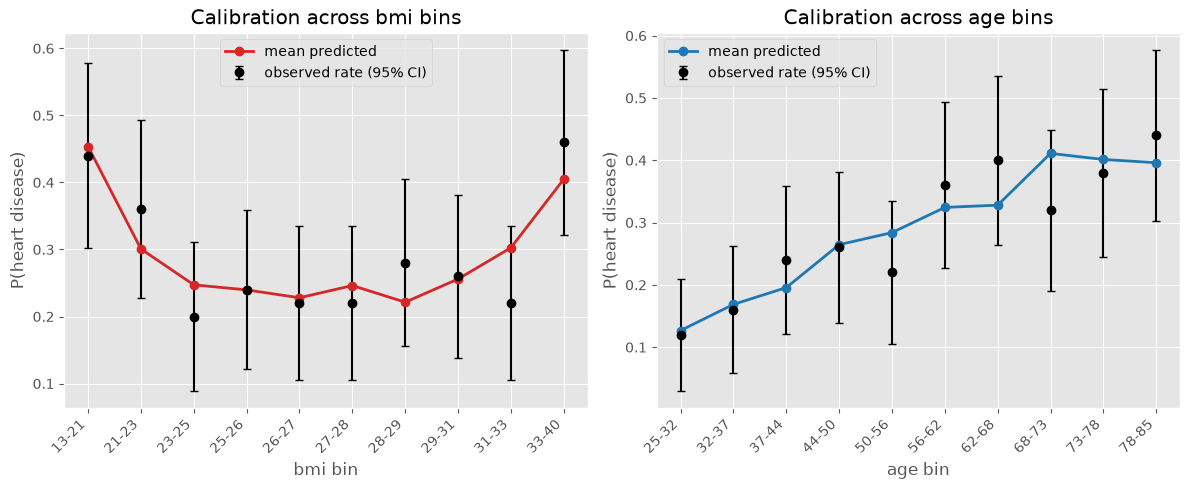

In [5]:
predicted_prob = model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, predictor, name, color in [(axes[0], bmi, "bmi", "tab:red"),
                                    (axes[1], age, "age", "tab:blue")]:
    cal = calibration_by(predictor, heart_disease, predicted_prob)

    positions = np.arange(len(cal))
    labels = [f"{lo:.0f}-{hi:.0f}" for lo, hi in zip(cal["bin_low"], cal["bin_high"])]
    ax.errorbar(positions, cal["observed_rate"], yerr=1.96 * cal["standard_error"],
                fmt="o", color="k", capsize=3, label="observed rate (95% CI)")
    ax.plot(positions, cal["predicted_rate"], "-o", color=color, lw=2,
            label="mean predicted")
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel(f"{name} bin")
    ax.set_ylabel("P(heart disease)")
    ax.set_title(f"Calibration across {name} bins")
    ax.legend()

plt.tight_layout()
plt.show()


The calibration plots show the probability of heart disease at different levels of bmi and age. Each error bar shows the observed event rate in a bin, with its 95% confidence interval. The colored lines show the model's mean predicted probability within each bin. The model captures nonlinearity on bmi well.


## Testing Nonlinearity for Reporting

A major advantage of regression splines over nonparametric smoothers is that we can perform formal hypothesis tests. In this way, we can report whether the nonlinearity assumption actually makes sense.

To do this we can compare a linear model against the spline model using a likelihood ratio test:

$\chi^2 = 2\left(LL_{\text{full}} - LL_{\text{reduced}}\right)$

where

$LL_{\text{full}}$ is the log likelihood of the model where the predictor enters as a spline,

$LL_{\text{reduced}}$ is the log likelihood of the model where the same predictor enters linearly.

Under $H_0$, this statistic follows a $\chi^2$ distribution with degrees of freedom equal to the extra parameters the spline spends:

$\text{df} = \text{df}_{\text{spline}} - 1$

The hypotheses are:

$H_0$: The relationship is linear.

$H_1$: The relationship is nonlinear.


In [6]:
full_llf = model.llf
nonlinearity_specs = {
    "bmi": {
        "reduced_formula": "bmi + cr(age, df=3, constraints='center') + smoke",
        "spline_cols": [c for c in X.columns if "bmi" in c],
    },
    "age": {
        "reduced_formula": "cr(bmi, df=4, constraints='center') + age + smoke",
        "spline_cols": [c for c in X.columns if "age" in c],
    },
}

nonlinearity_results = []
for name, spec in nonlinearity_specs.items():
    X_reduced = dmatrix(spec["reduced_formula"],
                        {"bmi": bmi, "age": age, "smoke": smoke},
                        return_type="dataframe")
    model_reduced = sm.Logit(heart_disease, X_reduced).fit(disp=False)

    dof = len(spec["spline_cols"]) - 1
    chi2_stat = 2 * (full_llf - model_reduced.llf)
    p_value = stats.chi2.sf(chi2_stat, dof)
    nonlinearity_results.append([name, dof, chi2_stat, p_value])

nonlinearity_df = pd.DataFrame(
    nonlinearity_results,
    columns=["predictor", "dof", "chi2", "p_value"],
)

nonlinearity_df

,predictor,dof,chi2,p_value
0,bmi,3,18.478592,0.000350
1,age,2,1.469318,0.479669


The results are compatible with the calibration plots. Bmi is nonlinear. On the other hand, we do not have enough evidence to conclude the same for the age variable.

## Determining Predictor Importance Using Partial Association

So far, we determined how many dof we have based on the sample size and selected the features we believe to be important. Finally we distribute the dof towards these features.

After model fitting, we can test the predictor importance using partial associations. For logistic models, we do the following for each variable:

- We fit a full model and a model not having the predictor we are interested in.
- Measure log likelihood of each model.
- Calculate log likelihood ratio:

$\chi^2 = 2(LL_{full}-LL_{reduced})$

Finally rank predictors based on $\chi^2 - \text{dof}$. We subtract $\text{dof}$ because complexity gives an unfair advantage to the predictor in consideration. By adding a penalizing component, we balance this outcome.

In [7]:
model_full = sm.Logit(heart_disease, X).fit(disp=False)
full_model_likelihood = model_full.llf

predictor_blocks = {
    "bmi":   [c for c in X.columns if "bmi" in c],
    "age":   [c for c in X.columns if "age" in c],
    "smoke": ["smoke"],
}

predictor_importance = []
for predictor, cols in predictor_blocks.items():
    X_reduced = X.drop(columns=cols)
    model_reduced = sm.Logit(heart_disease, X_reduced).fit(disp=False)
    dof = len(cols)
    likelihood_ratio_stat = 2 * (full_model_likelihood - model_reduced.llf)
    rank_variable = likelihood_ratio_stat - dof
    predictor_importance.append([predictor, dof, likelihood_ratio_stat, rank_variable])

predictor_importance_df = pd.DataFrame(
    predictor_importance,
    columns=["predictor", "dof", "chi2", "chi2_minus_dof"],
).sort_values(by="chi2_minus_dof", ascending=False)

predictor_importance_df


,predictor,dof,chi2,chi2_minus_dof
1,age,3,23.173235,20.173235
0,bmi,4,19.123680,15.123680
2,smoke,1,15.800694,14.800694


From the partial association, `age` variable seems to be more important compared to `bmi`.

This might look like a contradiction. The nonlinearity test said age is essentially linear, but here age comes out as the most important variable. The reason is that the two tests answer different questions. Partial association asks how strongly a variable is related to the outcome. The nonlinearity test asks whether that relationship is curved. A variable can be important and linear at the same time, which is exactly the case for age.

Note that we cannot change the model based on this result. Doing so is a data-driven decision (introduces bias) which is not acceptable statistical inference.

Prespecifying model complexity on regression tasks is similar to what we have done in the example above with some nuances. We use all the samples in dof analysis (rather than the minority class). Also, we use the F-test instead of the likelihood ratio test. This applies both to the nonlinearity test and to partial association. The rest is the same.